In [ ]:
# ============================================================
# ONE-CELL ALPACA STATIONARY POINT DIAGNOSTIC
# Top 5 XLK-style stocks
# Finds confirmed maxima/minima and where bot would buy/sell
# ============================================================

# If needed, uncomment this once:
# !pip install alpaca-py

import os
import numpy as np
import pandas as pd

from datetime import datetime
from zoneinfo import ZoneInfo

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from alpaca.data.enums import DataFeed


# ============================================================
# 1. USER SETTINGS
# ============================================================

TICKERS = ["NVDA", "AAPL", "MSFT", "AVGO", "MU"]

NY_TZ = ZoneInfo("America/New_York")

# Change this to whatever trading day you want to test.
# Format: year, month, day, hour, minute
START_TIME = datetime(2026, 5, 20, 9, 30, tzinfo=NY_TZ)
END_TIME   = datetime(2026, 5, 20, 16, 0, tzinfo=NY_TZ)

# Alpaca can do custom minute bars.
# Try 3, 5, 10, 15, etc.
BAR_MINUTES = 1
TIMEFRAME = TimeFrame(BAR_MINUTES, TimeFrameUnit.Minute)

# If you are on Alpaca free data, use IEX.
# If you have SIP data access, you can change this to DataFeed.SIP.
DATA_FEED = DataFeed.IEX

# Stationary point settings
SMOOTH_WINDOW = 5
VOL_WINDOW = 20
ATR_WINDOW = 14

# ORDER means how many candles on each side are used to confirm a point.
# Example:
# BAR_MINUTES = 5 and ORDER = 3
# means confirmation delay is 15 minutes.
ORDER = 3

# Reject tiny swings.
# 0.001 = 0.1%
# 0.002 = 0.2%
# Set to 0.0 if you want no swing filter.
MIN_SWING_PCT = 0.001


# ============================================================
# 2. ALPACA API KEYS
# ============================================================

# Recommended:
# Store your keys as environment variables:
#
# Windows PowerShell:
# setx ALPACA_API_KEY "your_key_here"
# setx ALPACA_SECRET_KEY "your_secret_here"
#
# Then restart VS Code/Jupyter.

ALPACA_API_KEY = ""
ALPACA_SECRET_KEY = ""

if ALPACA_API_KEY is None or ALPACA_SECRET_KEY is None:
    raise ValueError(
        "Missing Alpaca keys. Set ALPACA_API_KEY and ALPACA_SECRET_KEY "
        "as environment variables, or paste them into the variables above."
    )

stock_client = StockHistoricalDataClient(
    ALPACA_API_KEY,
    ALPACA_SECRET_KEY
)


# ============================================================
# 3. FEATURE FUNCTIONS
# ============================================================

def compute_atr(df, window=14):
    high = df["High"]
    low = df["Low"]
    close = df["Close"]
    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    return true_range.rolling(window=window, min_periods=window).mean()


def prepare_features(df):
    df = df.copy()

    df["smooth_price"] = (
        df["Close"]
        .rolling(window=SMOOTH_WINDOW, min_periods=SMOOTH_WINDOW)
        .mean()
    )

    df["first_derivative"] = df["smooth_price"].diff()
    df["second_derivative"] = df["first_derivative"].diff()

    df["returns"] = df["Close"].pct_change()

    df["rolling_volatility"] = (
        df["returns"]
        .rolling(window=VOL_WINDOW, min_periods=VOL_WINDOW)
        .std()
    )

    df["ATR"] = compute_atr(df, window=ATR_WINDOW)
    df["ATR_percent"] = df["ATR"] / df["Close"]

    return df


# ============================================================
# 4. ALPACA DATA FETCH
# ============================================================

def get_alpaca_stock_bars(symbols, start_time, end_time, timeframe, feed=DataFeed.IEX):
    request = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=timeframe,
        start=start_time,
        end=end_time,
        feed=feed
    )

    bars = stock_client.get_stock_bars(request)
    df = bars.df

    if df.empty:
        return pd.DataFrame()

    df = df.reset_index()

    rename_map = {
        "symbol": "ticker",
        "timestamp": "time",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume",
        "trade_count": "TradeCount",
        "vwap": "VWAP"
    }

    df = df.rename(columns=rename_map)

    # Convert timestamps to New York time for readability
    if df["time"].dt.tz is None:
        df["time"] = df["time"].dt.tz_localize("UTC")

    df["time"] = df["time"].dt.tz_convert(NY_TZ)

    df = df.sort_values(["ticker", "time"]).reset_index(drop=True)

    return df


# ============================================================
# 5. CANDIDATE EXTREMA DETECTION
# ============================================================

def detect_candidate_extrema(df, order=3, price_col="smooth_price"):
    """
    Detects candidate local minima/maxima.

    This does NOT force alternation.
    It only finds points that independently look like real extrema.

    A candidate minimum needs:
        - price falling into the point
        - point is lowest nearby
        - price rises after

    A candidate maximum needs:
        - price rising into the point
        - point is highest nearby
        - price falls after
    """

    candidates = []

    for i in range(order, len(df) - order):
        current_price = df[price_col].iloc[i]

        if pd.isna(current_price):
            continue

        window = df[price_col].iloc[i - order : i + order + 1]

        if window.isna().any():
            continue

        left_price = df[price_col].iloc[i - order]
        right_price = df[price_col].iloc[i + order]

        was_falling_before = current_price < left_price
        rises_after = right_price > current_price

        was_rising_before = current_price > left_price
        falls_after = right_price < current_price

        is_lowest_nearby = current_price == window.min()
        is_highest_nearby = current_price == window.max()

        if is_lowest_nearby and was_falling_before and rises_after:
            candidates.append({
                "idx": i,
                "extremum_time": df.index[i],
                "stationary_type": "local_minimum",
                "extremum_price": df["Close"].iloc[i],
                "smooth_extremum_price": df["smooth_price"].iloc[i],
            })

        elif is_highest_nearby and was_rising_before and falls_after:
            candidates.append({
                "idx": i,
                "extremum_time": df.index[i],
                "stationary_type": "local_maximum",
                "extremum_price": df["Close"].iloc[i],
                "smooth_extremum_price": df["smooth_price"].iloc[i],
            })

    return pd.DataFrame(candidates)


# ============================================================
# 6. VALIDATE EXTREMA USING YOUR CORRECTED RULE
# ============================================================

def validate_extrema_sequence(candidates_df, min_swing_pct=0.001):
    """
    Validation rule:

    Candidate minimum:
        confirm only if its price is below the previous confirmed maximum.

    Candidate maximum:
        confirm only if its price is above the previous confirmed minimum.

    This does not force alternation.
    It only validates or rejects already-detected candidate extrema.

    Same-type candidates:
        - repeated maxima: keep the higher one
        - repeated minima: keep the lower one
    """

    if candidates_df.empty:
        return candidates_df.copy()

    candidates_df = candidates_df.sort_values("extremum_time").reset_index(drop=True)

    confirmed = []

    for _, row in candidates_df.iterrows():
        curr = row.to_dict()
        curr_type = curr["stationary_type"]
        curr_price = curr["extremum_price"]

        # First candidate becomes initial reference.
        if len(confirmed) == 0:
            curr["validation_status"] = "confirmed_initial_reference"
            curr["swing_from_previous_pct"] = np.nan
            confirmed.append(curr)
            continue

        last = confirmed[-1]
        last_type = last["stationary_type"]
        last_price = last["extremum_price"]

        # Same-type candidate: keep the more extreme one.
        if curr_type == last_type:
            if curr_type == "local_maximum" and curr_price > last_price:
                curr["validation_status"] = "confirmed_replaced_lower_maximum"
                curr["swing_from_previous_pct"] = np.nan
                confirmed[-1] = curr

            elif curr_type == "local_minimum" and curr_price < last_price:
                curr["validation_status"] = "confirmed_replaced_higher_minimum"
                curr["swing_from_previous_pct"] = np.nan
                confirmed[-1] = curr

            continue

        # Candidate minimum after previous confirmed maximum.
        # It must be lower than the previous max.
        if curr_type == "local_minimum" and last_type == "local_maximum":
            swing_pct = (last_price - curr_price) / last_price

            if curr_price < last_price and swing_pct >= min_swing_pct:
                curr["validation_status"] = "confirmed_min_below_previous_max"
                curr["swing_from_previous_pct"] = swing_pct
                confirmed.append(curr)

        # Candidate maximum after previous confirmed minimum.
        # It must be higher than the previous min.
        elif curr_type == "local_maximum" and last_type == "local_minimum":
            swing_pct = (curr_price - last_price) / last_price

            if curr_price > last_price and swing_pct >= min_swing_pct:
                curr["validation_status"] = "confirmed_max_above_previous_min"
                curr["swing_from_previous_pct"] = swing_pct
                confirmed.append(curr)

    return pd.DataFrame(confirmed)


# ============================================================
# 7. BUILD FINAL SIGNAL TABLE
# ============================================================

def build_signal_table(df, ticker, confirmed_df, order=3):
    """
    Builds the final diagnostic table.

    extremum_time:
        when the actual turning point happened.

    confirmation_time:
        when the bot could realistically know the point was confirmed.

    bot_action:
        local_minimum -> BUY / REINVEST CHECK
        local_maximum -> PROFIT-SELL CHECK
    """

    if confirmed_df.empty:
        return pd.DataFrame()

    rows = []

    for _, point in confirmed_df.iterrows():
        i = int(point["idx"])
        confirmation_i = i + order

        if confirmation_i >= len(df):
            continue

        stationary_type = point["stationary_type"]

        if stationary_type == "local_minimum":
            bot_action = "BUY / REINVEST CHECK"
        elif stationary_type == "local_maximum":
            bot_action = "PROFIT-SELL CHECK"
        else:
            bot_action = "NO ACTION"

        extremum_row = df.iloc[i]
        confirmation_row = df.iloc[confirmation_i]

        rows.append({
            "ticker": ticker,
            "stationary_type": stationary_type,
            "bot_action": bot_action,

            "extremum_time": df.index[i],
            "confirmation_time": df.index[confirmation_i],

            "extremum_price": extremum_row["Close"],
            "confirmation_price": confirmation_row["Close"],

            "open": extremum_row["Open"],
            "high": extremum_row["High"],
            "low": extremum_row["Low"],
            "close": extremum_row["Close"],
            "volume": extremum_row["Volume"],

            "smooth_price": extremum_row["smooth_price"],
            "first_derivative": extremum_row["first_derivative"],
            "second_derivative": extremum_row["second_derivative"],

            "rolling_volatility": extremum_row["rolling_volatility"],
            "ATR": extremum_row["ATR"],
            "ATR_percent": extremum_row["ATR_percent"],

            "swing_from_previous_pct": point.get("swing_from_previous_pct", np.nan),
            "validation_status": point.get("validation_status", "")
        })

    return pd.DataFrame(rows)


# ============================================================
# 8. RUN FULL SCAN
# ============================================================

print("=" * 100)
print("Downloading Alpaca stock bars...")
print("=" * 100)

raw_bars_df = get_alpaca_stock_bars(
    symbols=TICKERS,
    start_time=START_TIME,
    end_time=END_TIME,
    timeframe=TIMEFRAME,
    feed=DATA_FEED
)

if raw_bars_df.empty:
    raise ValueError("No Alpaca bar data returned. Check ticker symbols, dates, market hours, and data feed.")

print(f"Downloaded {len(raw_bars_df)} rows.")
print(f"Bar interval: {BAR_MINUTES} minute(s)")
print(f"Session: {START_TIME} to {END_TIME}")
print("\n")

stationary_tables_by_ticker = {}

for ticker in TICKERS:
    ticker_df = raw_bars_df[raw_bars_df["ticker"] == ticker].copy()

    if ticker_df.empty:
        print(f"No data for {ticker}")
        stationary_tables_by_ticker[ticker] = pd.DataFrame()
        continue

    ticker_df = ticker_df.set_index("time").sort_index()

    ticker_df = prepare_features(ticker_df)

    candidates_df = detect_candidate_extrema(
        ticker_df,
        order=ORDER,
        price_col="smooth_price"
    )

    confirmed_df = validate_extrema_sequence(
        candidates_df,
        min_swing_pct=MIN_SWING_PCT
    )

    signal_table = build_signal_table(
        df=ticker_df,
        ticker=ticker,
        confirmed_df=confirmed_df,
        order=ORDER
    )

    if not signal_table.empty:
        signal_table = signal_table.sort_values("extremum_time").reset_index(drop=True)

        numeric_cols = [
            "extremum_price",
            "confirmation_price",
            "open",
            "high",
            "low",
            "close",
            "smooth_price",
            "first_derivative",
            "second_derivative",
            "rolling_volatility",
            "ATR",
            "ATR_percent",
            "swing_from_previous_pct"
        ]

        for col in numeric_cols:
            if col in signal_table.columns:
                signal_table[col] = signal_table[col].round(6)

    stationary_tables_by_ticker[ticker] = signal_table


# ============================================================
# 9. DISPLAY SEPARATE TABLE PER COMPANY
# ============================================================

for ticker, table in stationary_tables_by_ticker.items():
    print("=" * 100)
    print(f"{ticker} confirmed stationary points and bot action table")
    print("=" * 100)

    if table.empty:
        print(f"No confirmed stationary points found for {ticker}.")
    else:
        print(f"Found {len(table)} confirmed stationary points for {ticker}.")
        display(table)

    print("\n")

Downloaded 1951 rows.
Bar interval: 1 minute(s)
Session: 2026-05-20 09:30:00-04:00 to 2026-05-20 16:00:00-04:00


NVDA confirmed stationary points and bot action table
Found 20 confirmed stationary points for NVDA.


,ticker,stationary_type,bot_action,extremum_time,confirmation_time,extremum_price,confirmation_price,open,high,low,close,volume,smooth_price,first_derivative,second_derivative,rolling_volatility,ATR,ATR_percent,swing_from_previous_pct,validation_status
0,NVDA,local_minimum,BUY / REINVEST CHECK,2026-05-20 09:40:00-04:00,2026-05-20 09:43:00-04:00,221.680,221.910,221.080,221.680,220.850,221.680,28343.0,221.127,-0.044,0.188,NaN,NaN,NaN,NaN,confirmed_initial_reference
1,NVDA,local_maximum,PROFIT-SELL CHECK,2026-05-20 09:48:00-04:00,2026-05-20 09:51:00-04:00,222.230,221.400,222.135,222.310,222.100,222.230,20586.0,222.062,0.064,-0.096,NaN,0.581071,0.002615,0.002481,confirmed_max_above_previous_min
2,NVDA,local_minimum,BUY / REINVEST CHECK,2026-05-20 09:58:00-04:00,2026-05-20 10:01:00-04:00,221.755,222.075,222.005,222.005,221.470,221.755,11964.0,221.486,-0.035,-0.050,0.001939,0.605000,0.002728,0.002137,confirmed_min_below_previous_max
3,NVDA,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:34:00-04:00,2026-05-20 10:37:00-04:00,224.850,224.400,224.620,225.020,224.615,224.850,9864.0,224.696,0.116,0.008,0.001530,0.401071,0.001784,NaN,confirmed_replaced_lower_maximum
4,NVDA,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:37:00-04:00,2026-05-20 10:40:00-04:00,224.400,225.230,224.620,224.680,224.400,224.400,14680.0,224.532,-0.072,-0.006,0.001542,0.378929,0.001689,0.002001,confirmed_min_below_previous_max
5,NVDA,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:42:00-04:00,2026-05-20 10:45:00-04:00,224.720,224.760,224.860,224.935,224.655,224.720,26320.0,224.858,0.064,0.011,0.001534,0.392857,0.001748,0.001426,confirmed_max_above_previous_min
6,NVDA,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:50:00-04:00,2026-05-20 10:53:00-04:00,224.160,224.645,224.130,224.260,224.040,224.160,9857.0,224.184,-0.120,0.038,0.001465,0.383571,0.001711,0.002492,confirmed_min_below_previous_max
7,NVDA,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:24:00-04:00,2026-05-20 11:27:00-04:00,225.670,225.320,225.535,225.690,225.500,225.670,8874.0,225.612,0.014,-0.018,0.000846,0.337500,0.001496,NaN,confirmed_replaced_lower_maximum
8,NVDA,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:41:00-04:00,2026-05-20 11:44:00-04:00,224.900,225.150,224.820,224.900,224.800,224.900,4539.0,224.930,-0.064,0.093,0.000674,0.235000,0.001045,NaN,confirmed_replaced_higher_minimum
9,NVDA,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:49:00-04:00,2026-05-20 11:52:00-04:00,225.200,224.990,224.980,225.205,224.980,225.200,4309.0,225.137,0.010,0.011,0.000664,0.214643,0.000953,0.001334,confirmed_max_above_previous_min




AAPL confirmed stationary points and bot action table
Found 12 confirmed stationary points for AAPL.


,ticker,stationary_type,bot_action,extremum_time,confirmation_time,extremum_price,confirmation_price,open,high,low,close,volume,smooth_price,first_derivative,second_derivative,rolling_volatility,ATR,ATR_percent,swing_from_previous_pct,validation_status
0,AAPL,local_maximum,PROFIT-SELL CHECK,2026-05-20 09:47:00-04:00,2026-05-20 09:50:00-04:00,301.525,301.510,301.695,301.845,301.460,301.525,4179.0,301.725,0.089,-0.129,NaN,0.547500,0.001816,NaN,confirmed_replaced_lower_maximum
1,AAPL,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:13:00-04:00,2026-05-20 10:16:00-04:00,299.350,300.140,299.440,299.440,299.235,299.350,2870.0,299.386,-0.051,0.049,0.000650,0.289643,0.000968,0.007213,confirmed_min_below_previous_max
2,AAPL,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:20:00-04:00,2026-05-20 10:23:00-04:00,299.930,299.780,299.755,299.985,299.725,299.930,7987.0,299.917,0.055,0.012,0.000654,0.331429,0.001105,0.001938,confirmed_max_above_previous_min
3,AAPL,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:41:00-04:00,2026-05-20 10:44:00-04:00,299.225,299.600,299.300,299.320,299.220,299.225,3380.0,299.235,-0.061,-0.011,0.000725,0.241429,0.000807,NaN,confirmed_replaced_higher_minimum
4,AAPL,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:56:00-04:00,2026-05-20 10:59:00-04:00,300.220,299.930,300.250,300.320,300.220,300.220,3292.0,300.322,0.012,-0.092,0.000574,0.198571,0.000661,0.003325,confirmed_max_above_previous_min
5,AAPL,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:11:00-04:00,2026-05-20 11:14:00-04:00,299.210,299.235,299.300,299.350,299.210,299.210,969.0,299.212,-0.012,0.002,0.000417,0.174643,0.000584,0.003364,confirmed_min_below_previous_max
6,AAPL,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:26:00-04:00,2026-05-20 11:29:00-04:00,299.720,299.150,299.675,299.790,299.650,299.720,3252.0,299.650,0.012,0.002,0.000985,0.313571,0.001046,NaN,confirmed_replaced_lower_maximum
7,AAPL,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:44:00-04:00,2026-05-20 11:47:00-04:00,298.965,298.980,298.860,298.970,298.860,298.965,1246.0,298.869,-0.017,0.015,0.000550,0.179643,0.000601,NaN,confirmed_replaced_higher_minimum
8,AAPL,local_maximum,PROFIT-SELL CHECK,2026-05-20 15:03:00-04:00,2026-05-20 15:06:00-04:00,302.310,301.940,302.510,302.510,302.260,302.310,12748.0,302.467,0.023,-0.030,0.000539,0.174286,0.000577,NaN,confirmed_replaced_lower_maximum
9,AAPL,local_minimum,BUY / REINVEST CHECK,2026-05-20 15:10:00-04:00,2026-05-20 15:13:00-04:00,301.875,302.185,301.615,301.935,301.500,301.875,14534.0,301.810,-0.023,0.059,0.000496,0.206429,0.000684,0.001439,confirmed_min_below_previous_max




MSFT confirmed stationary points and bot action table
Found 22 confirmed stationary points for MSFT.


,ticker,stationary_type,bot_action,extremum_time,confirmation_time,extremum_price,confirmation_price,open,high,low,close,volume,smooth_price,first_derivative,second_derivative,rolling_volatility,ATR,ATR_percent,swing_from_previous_pct,validation_status
0,MSFT,local_minimum,BUY / REINVEST CHECK,2026-05-20 09:44:00-04:00,2026-05-20 09:47:00-04:00,412.260,413.430,411.680,412.480,411.310,412.260,3775.0,412.517,-0.088,0.270,NaN,1.200357,0.002912,NaN,confirmed_initial_reference
1,MSFT,local_maximum,PROFIT-SELL CHECK,2026-05-20 09:50:00-04:00,2026-05-20 09:53:00-04:00,413.485,412.660,413.720,414.040,413.485,413.485,1978.0,413.773,0.092,-0.190,0.002082,0.987500,0.002388,0.002971,confirmed_max_above_previous_min
2,MSFT,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:12:00-04:00,2026-05-20 10:15:00-04:00,412.530,413.840,411.960,412.530,411.930,412.530,2047.0,412.094,-0.081,0.209,0.000934,0.517143,0.001254,NaN,confirmed_replaced_higher_minimum
3,MSFT,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:19:00-04:00,2026-05-20 10:22:00-04:00,414.380,413.345,414.510,414.670,414.380,414.380,1553.0,414.404,0.236,-0.066,0.001096,0.589643,0.001423,0.004485,confirmed_max_above_previous_min
4,MSFT,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:26:00-04:00,2026-05-20 10:29:00-04:00,413.050,413.890,412.740,413.135,412.720,413.050,2321.0,412.805,-0.064,0.122,0.001252,0.626786,0.001517,0.003210,confirmed_min_below_previous_max
5,MSFT,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:59:00-04:00,2026-05-20 11:02:00-04:00,416.140,415.890,416.300,416.550,416.140,416.140,1144.0,416.280,0.068,-0.032,0.000594,0.336071,0.000808,NaN,confirmed_replaced_lower_maximum
6,MSFT,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:08:00-04:00,2026-05-20 11:11:00-04:00,415.440,416.035,415.390,415.560,415.340,415.440,924.0,415.616,-0.046,0.076,0.000772,0.348214,0.000838,0.001682,confirmed_min_below_previous_max
7,MSFT,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:19:00-04:00,2026-05-20 11:22:00-04:00,417.330,416.980,416.980,417.415,416.980,417.330,1294.0,417.142,0.176,0.040,0.000810,0.441786,0.001059,0.004549,confirmed_max_above_previous_min
8,MSFT,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:40:00-04:00,2026-05-20 11:43:00-04:00,416.670,417.060,416.760,416.805,416.560,416.670,562.0,416.742,-0.056,-0.016,0.000363,0.207143,0.000497,NaN,confirmed_replaced_higher_minimum
9,MSFT,local_maximum,PROFIT-SELL CHECK,2026-05-20 12:10:00-04:00,2026-05-20 12:13:00-04:00,417.950,417.695,417.750,417.950,417.680,417.950,503.0,417.886,0.002,0.001,0.000511,0.275714,0.000660,NaN,confirmed_replaced_lower_maximum




AVGO confirmed stationary points and bot action table
Found 22 confirmed stationary points for AVGO.


,ticker,stationary_type,bot_action,extremum_time,confirmation_time,extremum_price,confirmation_price,open,high,low,close,volume,smooth_price,first_derivative,second_derivative,rolling_volatility,ATR,ATR_percent,swing_from_previous_pct,validation_status
0,AVGO,local_minimum,BUY / REINVEST CHECK,2026-05-20 09:41:00-04:00,2026-05-20 09:44:00-04:00,412.480,415.280,414.480,414.710,412.445,412.480,6155.0,413.479,-0.377,0.032,NaN,NaN,NaN,NaN,confirmed_initial_reference
1,AVGO,local_maximum,PROFIT-SELL CHECK,2026-05-20 09:48:00-04:00,2026-05-20 09:51:00-04:00,415.170,413.125,414.990,415.830,414.990,415.170,1899.0,414.729,0.210,0.057,NaN,1.400714,0.003374,0.006522,confirmed_max_above_previous_min
2,AVGO,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:06:00-04:00,2026-05-20 10:09:00-04:00,413.675,414.920,413.230,413.760,413.000,413.675,1557.0,413.037,-0.037,0.269,0.001956,0.969286,0.002343,NaN,confirmed_replaced_higher_minimum
3,AVGO,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:31:00-04:00,2026-05-20 10:34:00-04:00,420.990,419.450,420.570,420.990,420.340,420.990,1927.0,420.687,0.178,-0.072,0.002273,0.718929,0.001708,0.017683,confirmed_max_above_previous_min
4,AVGO,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:42:00-04:00,2026-05-20 10:45:00-04:00,418.125,419.470,418.150,418.450,417.990,418.125,1562.0,418.286,-0.113,0.049,0.001201,0.661071,0.001581,0.006805,confirmed_min_below_previous_max
5,AVGO,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:19:00-04:00,2026-05-20 11:22:00-04:00,422.390,422.415,421.630,422.760,421.490,422.390,1239.0,422.618,0.088,0.138,0.001101,0.740714,0.001754,NaN,confirmed_replaced_lower_maximum
6,AVGO,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:44:00-04:00,2026-05-20 11:47:00-04:00,420.680,421.310,420.580,420.720,420.580,420.680,542.0,420.886,-0.084,0.040,0.000768,0.414286,0.000985,NaN,confirmed_replaced_higher_minimum
7,AVGO,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:49:00-04:00,2026-05-20 11:52:00-04:00,421.220,420.900,421.100,421.220,421.100,421.220,335.0,421.286,0.108,-0.020,0.000668,0.341786,0.000811,0.001284,confirmed_max_above_previous_min
8,AVGO,local_minimum,BUY / REINVEST CHECK,2026-05-20 12:12:00-04:00,2026-05-20 12:15:00-04:00,419.670,419.720,419.670,419.670,419.465,419.670,855.0,419.656,-0.083,0.035,0.000552,0.291429,0.000694,NaN,confirmed_replaced_higher_minimum
9,AVGO,local_maximum,PROFIT-SELL CHECK,2026-05-20 12:14:00-04:00,2026-05-20 12:17:00-04:00,420.310,419.340,420.160,420.320,419.985,420.310,1107.0,419.944,0.152,0.016,0.000623,0.326429,0.000777,0.001525,confirmed_max_above_previous_min




MU confirmed stationary points and bot action table
Found 32 confirmed stationary points for MU.


,ticker,stationary_type,bot_action,extremum_time,confirmation_time,extremum_price,confirmation_price,open,high,low,close,volume,smooth_price,first_derivative,second_derivative,rolling_volatility,ATR,ATR_percent,swing_from_previous_pct,validation_status
0,MU,local_minimum,BUY / REINVEST CHECK,2026-05-20 09:39:00-04:00,2026-05-20 09:42:00-04:00,719.790,721.930,714.880,719.790,714.830,719.790,3819.0,717.514,-0.707,1.597,NaN,NaN,NaN,NaN,confirmed_initial_reference
1,MU,local_maximum,PROFIT-SELL CHECK,2026-05-20 09:47:00-04:00,2026-05-20 09:50:00-04:00,722.200,717.900,723.380,724.760,722.200,722.200,1912.0,723.468,0.054,-1.024,NaN,4.629643,0.006410,0.003348,confirmed_max_above_previous_min
2,MU,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:15:00-04:00,2026-05-20 10:18:00-04:00,707.565,705.280,705.730,707.585,704.900,707.565,3495.0,705.775,-0.415,0.747,0.003732,2.929286,0.004140,NaN,confirmed_replaced_higher_minimum
3,MU,local_maximum,PROFIT-SELL CHECK,2026-05-20 10:44:00-04:00,2026-05-20 10:47:00-04:00,712.370,709.970,711.000,712.370,710.460,712.370,852.0,712.686,0.322,0.238,0.002028,2.219643,0.003116,NaN,confirmed_replaced_lower_maximum
4,MU,local_minimum,BUY / REINVEST CHECK,2026-05-20 10:50:00-04:00,2026-05-20 10:53:00-04:00,709.800,714.990,709.520,710.450,709.180,709.800,1533.0,710.386,-0.386,0.145,0.001638,2.037143,0.002870,0.003608,confirmed_min_below_previous_max
5,MU,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:02:00-04:00,2026-05-20 11:05:00-04:00,719.000,716.380,720.830,720.830,719.000,719.000,2845.0,720.179,0.216,-0.884,0.001921,1.623571,0.002258,0.012961,confirmed_max_above_previous_min
6,MU,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:07:00-04:00,2026-05-20 11:10:00-04:00,716.600,719.000,719.210,720.000,716.600,716.600,1390.0,716.598,-0.480,-0.132,0.002410,2.037857,0.002844,0.003338,confirmed_min_below_previous_max
7,MU,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:20:00-04:00,2026-05-20 11:23:00-04:00,722.790,720.890,722.870,723.425,722.580,722.790,1077.0,722.112,0.126,-0.474,0.002449,2.057143,0.002846,0.008638,confirmed_max_above_previous_min
8,MU,local_minimum,BUY / REINVEST CHECK,2026-05-20 11:28:00-04:00,2026-05-20 11:31:00-04:00,719.910,722.870,718.940,719.970,718.920,719.910,517.0,719.347,-0.196,0.293,0.001876,1.883571,0.002616,0.003985,confirmed_min_below_previous_max
9,MU,local_maximum,PROFIT-SELL CHECK,2026-05-20 11:38:00-04:00,2026-05-20 11:41:00-04:00,725.280,724.760,725.000,726.440,724.755,725.280,1099.0,724.944,0.527,0.123,0.001451,1.365714,0.001883,0.007459,confirmed_max_above_previous_min


,ticker,time,stationary_type,signal_action,confirmation_price,extremum_time,extremum_price,validation_status
0,MU,2026-05-20 09:42:00-04:00,local_minimum,buy_check,721.930,2026-05-20 09:39:00-04:00,719.790,confirmed_initial_reference
1,NVDA,2026-05-20 09:43:00-04:00,local_minimum,buy_check,221.910,2026-05-20 09:40:00-04:00,221.680,confirmed_initial_reference
2,AVGO,2026-05-20 09:44:00-04:00,local_minimum,buy_check,415.280,2026-05-20 09:41:00-04:00,412.480,confirmed_initial_reference
3,MSFT,2026-05-20 09:47:00-04:00,local_minimum,buy_check,413.430,2026-05-20 09:44:00-04:00,412.260,confirmed_initial_reference
4,AAPL,2026-05-20 09:50:00-04:00,local_maximum,profit_sell_check,301.510,2026-05-20 09:47:00-04:00,301.525,confirmed_replaced_lower_maximum
...,...,...,...,...,...,...,...,...
103,AVGO,2026-05-20 15:43:00-04:00,local_minimum,buy_check,418.305,2026-05-20 15:40:00-04:00,418.050,confirmed_min_below_previous_max
104,NVDA,2026-05-20 15:50:00-04:00,local_maximum,profit_sell_check,223.150,2026-05-20 15:47:00-04:00,223.415,confirmed_replaced_lower_maximum
105,AVGO,2026-05-20 15:52:00-04:00,local_maximum,profit_sell_check,418.110,2026-05-20 15:49:00-04:00,418.590,confirmed_max_above_previous_min
106,MU,2026-05-20 15:52:00-04:00,local_maximum,profit_sell_check,730.680,2026-05-20 15:49:00-04:00,731.130,confirmed_max_above_previous_min


STATIONARY-POINT BUY / SELL / RISK BACKTEST RESULTS
Starting cash:          $1,500.00
Final equity:           $1,513.70
Final cash:             $227.52
Final position value:   $1,286.18
Total profit:           $13.70
Total return:           0.91%
Max drawdown:           0.60%
Kill switch triggered:  No


Buy trades:             54
Sell trades:            40
Realised sell count:    40
Win rate on sells:      95.00%
Gross realised profit:  $7.58
Gross realised loss:    $0.02
Profit factor:          495.23


Final per-ticker portfolio state


,ticker,cash_bucket,quantity,avg_entry_price,final_price,position_value,cost_basis,unrealised_pnl,unrealised_return_pct,total_ticker_value
0,NVDA,27.571070,1.224033,223.703751,223.48,273.546897,273.820775,-0.273878,-0.001000,301.117967
1,AAPL,25.670405,0.914488,300.336851,302.20,276.358191,274.654364,1.703827,0.006204,302.028596
2,MSFT,56.428904,0.589083,416.664333,420.36,247.626787,245.449734,2.177053,0.008870,304.055690
3,AVGO,54.847618,0.589461,417.971521,417.51,246.105707,246.377756,-0.272048,-0.001104,300.953326
4,MU,63.002466,0.331719,722.734467,731.16,242.540022,239.745108,2.794914,0.011658,305.542488


Trade log


,ticker,action,reason,time,price,quantity,gross_value,fee,net_value,stock_cash_after,cost_basis_sold,realised_pnl,realised_return_pct,unrealised_return_pct,unrealised_return_pct_before_sell,sell_fraction
0,MU,BUY,confirmed_minimum_buy_or_reinvest,2026-05-20 09:42:00-04:00,722.290965,0.207673,150.000000,0.0,150.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,NVDA,BUY,confirmed_minimum_buy_or_reinvest,2026-05-20 09:43:00-04:00,222.020955,0.675612,150.000000,0.0,150.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,AVGO,BUY,confirmed_minimum_buy_or_reinvest,2026-05-20 09:44:00-04:00,415.487640,0.361022,150.000000,0.0,150.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,MSFT,BUY,confirmed_minimum_buy_or_reinvest,2026-05-20 09:47:00-04:00,413.636715,0.362637,150.000000,0.0,150.000000,150.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,MU,NO_SELL,local_maximum_but_not_profitable,2026-05-20 09:50:00-04:00,717.900000,0.000000,0.000000,0.0,0.000000,150.000000,0.000000,0.000000,0.000000,-0.006079,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,AVGO,BUY,confirmed_minimum_buy_or_reinvest,2026-05-20 15:43:00-04:00,418.514152,0.065654,27.476935,0.0,27.476935,27.476935,NaN,NaN,NaN,NaN,NaN,NaN
103,NVDA,NO_SELL,local_maximum_but_not_profitable,2026-05-20 15:50:00-04:00,223.150000,0.000000,0.000000,0.0,0.000000,27.571070,0.000000,0.000000,0.000000,-0.002475,NaN,NaN
104,AVGO,SELL,confirmed_maximum_profit_take,2026-05-20 15:52:00-04:00,417.900945,0.065496,27.370684,0.0,27.370684,54.847618,27.375306,-0.004622,-0.000169,NaN,0.000331,0.100000
105,MU,SELL,confirmed_maximum_profit_take,2026-05-20 15:52:00-04:00,730.314660,0.040973,29.922963,0.0,29.922963,63.002466,29.612382,0.310581,0.010488,NaN,0.010994,0.109937


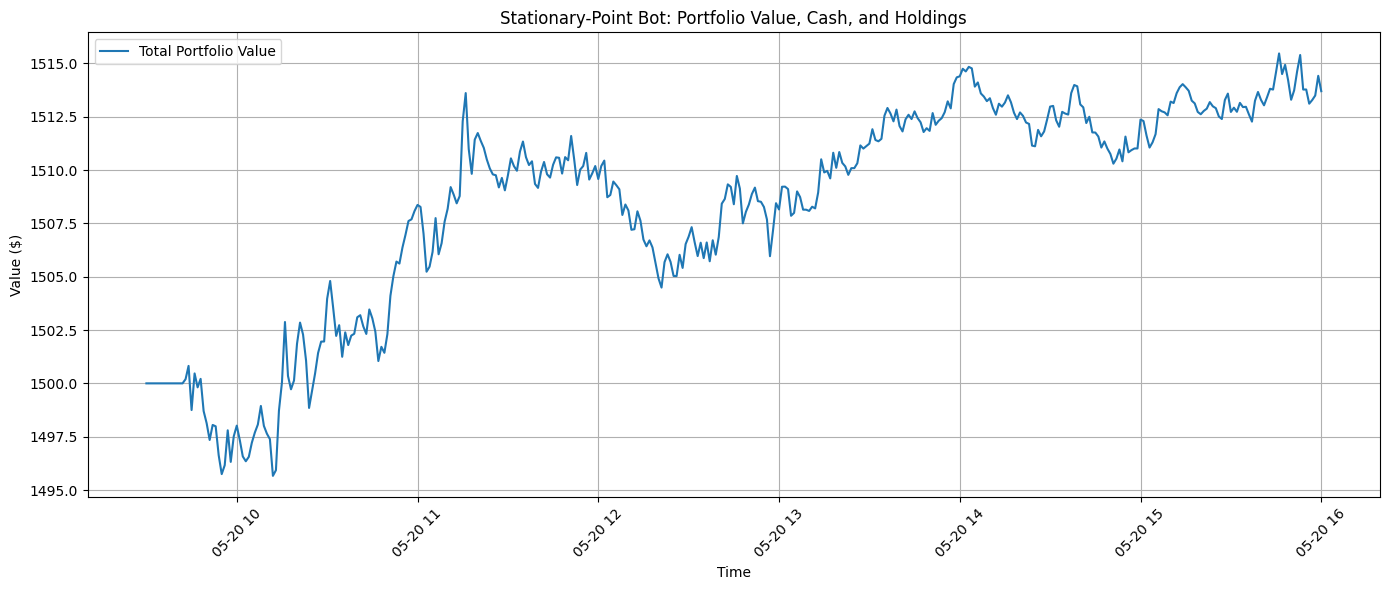

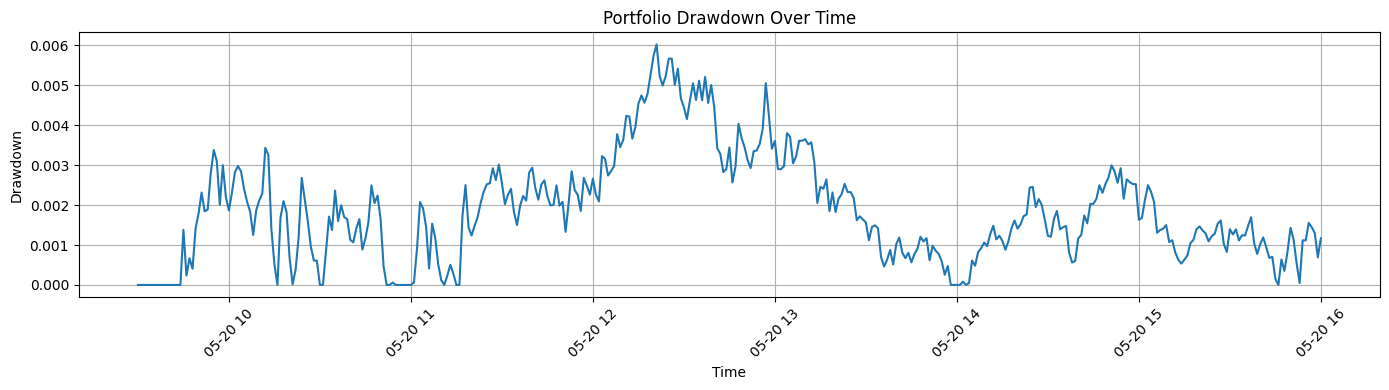

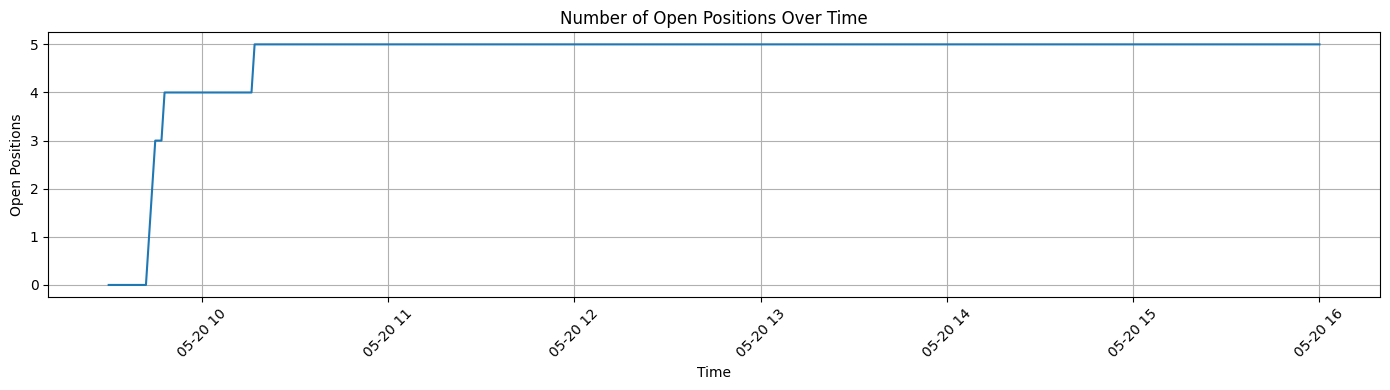

In [13]:
# ============================================================
# BUY / SELL / RISK BACKTEST CELL
# Uses output from stationary-point identifier cell
# Requires:
#   - raw_bars_df
#   - stationary_tables_by_ticker
#   - TICKERS
# ============================================================
import matplotlib.pyplot as plt

# ============================================================
# 1. BACKTEST SETTINGS
# ============================================================

STARTING_CASH = 1500.0

# Each ticker gets its own bucket.
# Example with 5 tickers and $1500:
# each ticker starts with $300.
INITIAL_CASH_PER_TICKER = STARTING_CASH / len(TICKERS)

# Buy only uses a fraction of that ticker's available cash bucket.
# 1.00 = use all available bucket cash at confirmed minimum.
# 0.50 = use half the available bucket cash.
BUY_FRACTION_OF_BUCKET = 0.50

MIN_TRADE_DOLLARS = 5.00

# Profit sell rule:
# sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER
# Example:
# +1% gain -> 10% sell
# +3% gain -> 30% sell
# +5% gain -> 50% sell
SELL_FRACTION_MULTIPLIER = 10.0

MIN_PROFIT_SELL_FRACTION = 0.10
MAX_PROFIT_SELL_FRACTION = 1.00

# Risk control:
# This is portfolio-level only.
# No ATR stop.
# No fixed percentage position stop.
# No position-level stop.
ENABLE_PORTFOLIO_KILL_SWITCH = True
PORTFOLIO_KILL_SWITCH = 0.03   # 3% drawdown from peak equity

# Optional end behaviour:
# False = do not force sell at end; final equity = cash + open position value.
# True = force close everything at final bar.
FORCE_CLOSE_AT_END = False

# Trading cost assumptions.
# For Alpaca stocks, commissions are usually zero, but keep slippage estimate.
FEE_RATE = 0.0
SLIPPAGE_RATE = 0.0005   # 0.05% assumed slippage


# ============================================================
# 2. SAFETY CHECKS
# ============================================================

required_objects = ["raw_bars_df", "stationary_tables_by_ticker", "TICKERS"]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(
            f"Missing {obj_name}. Run the stationary-point identifier cell first."
        )

if raw_bars_df.empty:
    raise ValueError("raw_bars_df is empty. Run the Alpaca data cell again.")

if len(stationary_tables_by_ticker) == 0:
    raise ValueError("stationary_tables_by_ticker is empty.")


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def calculate_profit_sell_fraction(unrealised_return):
    """
    unrealised_return:
        0.03 = +3%
        1.00 = +100%
        -0.02 = -2%

    Profit-taking only happens at confirmed local maximums.
    """

    if unrealised_return <= 0:
        return 0.0

    if unrealised_return >= 1.00:
        return 1.00

    sell_fraction = unrealised_return * SELL_FRACTION_MULTIPLIER

    sell_fraction = max(sell_fraction, MIN_PROFIT_SELL_FRACTION)
    sell_fraction = min(sell_fraction, MAX_PROFIT_SELL_FRACTION)

    return sell_fraction


def get_current_price(ticker, current_time, bars_by_ticker, last_known_prices):
    """
    Gets current close price for ticker at current_time.
    If exact row is unavailable, use last known price.
    """

    ticker_bars = bars_by_ticker.get(ticker)

    if ticker_bars is None or ticker_bars.empty:
        return last_known_prices.get(ticker, np.nan)

    if current_time in ticker_bars.index:
        price = ticker_bars.loc[current_time, "Close"]

        # If duplicate timestamps somehow occur, take the last one.
        if isinstance(price, pd.Series):
            price = price.iloc[-1]

        last_known_prices[ticker] = price
        return price

    return last_known_prices.get(ticker, np.nan)


def calculate_portfolio_value(stock_cash, positions, bars_by_ticker, current_time, last_known_prices):
    """
    Portfolio equity = all ticker cash buckets + current market value of positions.
    """

    total_cash = sum(stock_cash.values())
    position_value = 0.0

    per_ticker_values = {}

    for ticker in TICKERS:
        price = get_current_price(
            ticker=ticker,
            current_time=current_time,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices
        )

        pos = positions.get(ticker)

        if pos is None:
            ticker_position_value = 0.0
        else:
            ticker_position_value = pos["quantity"] * price if not pd.isna(price) else 0.0

        ticker_total_value = stock_cash[ticker] + ticker_position_value

        per_ticker_values[ticker] = {
            "cash": stock_cash[ticker],
            "position_value": ticker_position_value,
            "total_value": ticker_total_value,
            "price": price
        }

        position_value += ticker_position_value

    equity = total_cash + position_value

    return equity, total_cash, position_value, per_ticker_values


# ============================================================
# 4. PREPARE BAR DATA
# ============================================================

bars_df = raw_bars_df.copy()

# Make sure columns are in the expected format.
required_cols = {"ticker", "time", "Open", "High", "Low", "Close", "Volume"}
missing_cols = required_cols - set(bars_df.columns)

if missing_cols:
    raise ValueError(f"raw_bars_df is missing columns: {missing_cols}")

bars_by_ticker = {}

for ticker in TICKERS:
    ticker_bars = bars_df[bars_df["ticker"] == ticker].copy()

    if ticker_bars.empty:
        print(f"Warning: no bars found for {ticker}")
        continue

    ticker_bars = ticker_bars.set_index("time").sort_index()
    bars_by_ticker[ticker] = ticker_bars

all_times = sorted(bars_df["time"].unique())

if len(all_times) == 0:
    raise ValueError("No timestamps found in raw_bars_df.")


# ============================================================
# 5. PREPARE SIGNAL EVENTS
# ============================================================

signal_events = []

for ticker, table in stationary_tables_by_ticker.items():
    if table is None or table.empty:
        continue

    temp = table.copy()

    needed_cols = {"ticker", "stationary_type", "confirmation_time", "confirmation_price"}

    missing = needed_cols - set(temp.columns)
    if missing:
        raise ValueError(
            f"Stationary table for {ticker} is missing columns: {missing}"
        )

    for _, row in temp.iterrows():
        stationary_type = row["stationary_type"]

        if stationary_type == "local_minimum":
            signal_action = "buy_check"
        elif stationary_type == "local_maximum":
            signal_action = "profit_sell_check"
        else:
            continue

        signal_events.append({
            "ticker": ticker,
            "time": row["confirmation_time"],
            "stationary_type": stationary_type,
            "signal_action": signal_action,
            "confirmation_price": row["confirmation_price"],
            "extremum_time": row.get("extremum_time", pd.NaT),
            "extremum_price": row.get("extremum_price", np.nan),
            "validation_status": row.get("validation_status", "")
        })

signals_df = pd.DataFrame(signal_events)

if signals_df.empty:
    print("No signal events found. The backtest will not trade.")
else:
    signals_df = signals_df.sort_values(["time", "ticker"]).reset_index(drop=True)

display(signals_df)


# ============================================================
# 6. INITIALISE PORTFOLIO
# ============================================================

stock_cash = {
    ticker: INITIAL_CASH_PER_TICKER
    for ticker in TICKERS
}

positions = {
    ticker: None
    for ticker in TICKERS
}

last_known_prices = {}

for ticker in TICKERS:
    if ticker in bars_by_ticker and not bars_by_ticker[ticker].empty:
        first_price = bars_by_ticker[ticker]["Close"].iloc[0]
        last_known_prices[ticker] = first_price

trade_log = []
equity_curve = []

peak_equity = STARTING_CASH
trading_stopped = False
kill_switch_time = None


# ============================================================
# 7. MAIN BACKTEST LOOP
# ============================================================

for current_time in all_times:

    # ------------------------------------------------------------
    # Update portfolio value at current bar
    # ------------------------------------------------------------

    equity, total_cash, position_value, per_ticker_values = calculate_portfolio_value(
        stock_cash=stock_cash,
        positions=positions,
        bars_by_ticker=bars_by_ticker,
        current_time=current_time,
        last_known_prices=last_known_prices
    )

    peak_equity = max(peak_equity, equity)

    drawdown = (peak_equity - equity) / peak_equity if peak_equity > 0 else 0.0

    equity_curve.append({
        "time": current_time,
        "equity": equity,
        "cash": total_cash,
        "position_value": position_value,
        "drawdown": drawdown,
        "open_positions": sum(pos is not None for pos in positions.values())
    })

    # ------------------------------------------------------------
    # Portfolio-level risk control
    # ------------------------------------------------------------

    if (
        ENABLE_PORTFOLIO_KILL_SWITCH
        and not trading_stopped
        and drawdown >= PORTFOLIO_KILL_SWITCH
    ):
        trading_stopped = True
        kill_switch_time = current_time

        print(f"Portfolio kill switch triggered at {current_time}. Drawdown = {drawdown:.2%}")

        # Close all open positions due to portfolio-level risk.
        for ticker in TICKERS:
            pos = positions[ticker]

            if pos is None:
                continue

            current_price = get_current_price(
                ticker=ticker,
                current_time=current_time,
                bars_by_ticker=bars_by_ticker,
                last_known_prices=last_known_prices
            )

            if pd.isna(current_price):
                continue

            exit_price = current_price * (1 - SLIPPAGE_RATE)

            quantity_to_sell = pos["quantity"]
            gross_value = quantity_to_sell * exit_price
            fee = gross_value * FEE_RATE
            net_value = gross_value - fee

            cost_basis_sold = pos["cost_basis"]
            realised_pnl = net_value - cost_basis_sold

            stock_cash[ticker] += net_value

            trade_log.append({
                "ticker": ticker,
                "action": "SELL",
                "reason": "portfolio_kill_switch",
                "time": current_time,
                "price": exit_price,
                "quantity": quantity_to_sell,
                "gross_value": gross_value,
                "fee": fee,
                "net_value": net_value,
                "cost_basis_sold": cost_basis_sold,
                "realised_pnl": realised_pnl,
                "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
                "stock_cash_after": stock_cash[ticker]
            })

            positions[ticker] = None

        # After kill switch, no more trading.
        continue

    if trading_stopped:
        continue

    # ------------------------------------------------------------
    # Process signals that occur at this timestamp
    # ------------------------------------------------------------

    if not signals_df.empty:
        current_signals = signals_df[signals_df["time"] == current_time]
    else:
        current_signals = pd.DataFrame()

    if current_signals.empty:
        continue

    # Process sell checks before buy checks at the same timestamp.
    action_order = {
        "profit_sell_check": 0,
        "buy_check": 1
    }

    current_signals = current_signals.copy()
    current_signals["action_order"] = current_signals["signal_action"].map(action_order)
    current_signals = current_signals.sort_values(["action_order", "ticker"])

    for _, signal in current_signals.iterrows():
        ticker = signal["ticker"]
        signal_action = signal["signal_action"]

        current_price = get_current_price(
            ticker=ticker,
            current_time=current_time,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices
        )

        if pd.isna(current_price):
            continue

        # ========================================================
        # SELL LOGIC
        # ========================================================
        # Profit-taking only happens at confirmed local maximums.
        # If unrealised gain <= 0, sell nothing.
        # If gain > 0, sell proportional fraction.
        # If gain >= 100%, sell all.
        # ========================================================

        if signal_action == "profit_sell_check":
            pos = positions[ticker]

            if pos is None:
                continue

            market_value = pos["quantity"] * current_price
            unrealised_pnl = market_value - pos["cost_basis"]
            unrealised_return = unrealised_pnl / pos["cost_basis"] if pos["cost_basis"] > 0 else 0.0

            sell_fraction = calculate_profit_sell_fraction(unrealised_return)

            if sell_fraction <= 0:
                trade_log.append({
                    "ticker": ticker,
                    "action": "NO_SELL",
                    "reason": "local_maximum_but_not_profitable",
                    "time": current_time,
                    "price": current_price,
                    "quantity": 0.0,
                    "gross_value": 0.0,
                    "fee": 0.0,
                    "net_value": 0.0,
                    "cost_basis_sold": 0.0,
                    "realised_pnl": 0.0,
                    "realised_return_pct": 0.0,
                    "unrealised_return_pct": unrealised_return,
                    "stock_cash_after": stock_cash[ticker]
                })
                continue

            quantity_to_sell = pos["quantity"] * sell_fraction

            exit_price = current_price * (1 - SLIPPAGE_RATE)
            gross_value = quantity_to_sell * exit_price
            fee = gross_value * FEE_RATE
            net_value = gross_value - fee

            cost_basis_sold = pos["cost_basis"] * sell_fraction
            realised_pnl = net_value - cost_basis_sold

            stock_cash[ticker] += net_value

            pos["quantity"] -= quantity_to_sell
            pos["cost_basis"] -= cost_basis_sold

            if pos["quantity"] <= 1e-10 or sell_fraction >= 1.0:
                positions[ticker] = None
            else:
                positions[ticker] = pos

            trade_log.append({
                "ticker": ticker,
                "action": "SELL",
                "reason": "confirmed_maximum_profit_take",
                "time": current_time,
                "price": exit_price,
                "quantity": quantity_to_sell,
                "gross_value": gross_value,
                "fee": fee,
                "net_value": net_value,
                "cost_basis_sold": cost_basis_sold,
                "realised_pnl": realised_pnl,
                "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
                "unrealised_return_pct_before_sell": unrealised_return,
                "sell_fraction": sell_fraction,
                "stock_cash_after": stock_cash[ticker]
            })

        # ========================================================
        # BUY LOGIC
        # ========================================================
        # Buy/reinvest only happens at confirmed local minimums.
        # Uses only that ticker's own cash bucket.
        # ========================================================

        elif signal_action == "buy_check":
            available_cash = stock_cash[ticker]

            if available_cash < MIN_TRADE_DOLLARS:
                trade_log.append({
                    "ticker": ticker,
                    "action": "NO_BUY",
                    "reason": "not_enough_ticker_cash",
                    "time": current_time,
                    "price": current_price,
                    "quantity": 0.0,
                    "gross_value": 0.0,
                    "fee": 0.0,
                    "net_value": 0.0,
                    "stock_cash_after": stock_cash[ticker]
                })
                continue

            amount_to_spend = available_cash * BUY_FRACTION_OF_BUCKET

            if amount_to_spend < MIN_TRADE_DOLLARS:
                trade_log.append({
                    "ticker": ticker,
                    "action": "NO_BUY",
                    "reason": "trade_too_small",
                    "time": current_time,
                    "price": current_price,
                    "quantity": 0.0,
                    "gross_value": 0.0,
                    "fee": 0.0,
                    "net_value": 0.0,
                    "stock_cash_after": stock_cash[ticker]
                })
                continue

            entry_price = current_price * (1 + SLIPPAGE_RATE)

            quantity_to_buy = amount_to_spend / entry_price
            gross_cost = quantity_to_buy * entry_price
            fee = gross_cost * FEE_RATE
            total_cost = gross_cost + fee

            if total_cost > stock_cash[ticker]:
                total_cost = stock_cash[ticker]
                gross_cost = total_cost / (1 + FEE_RATE)
                fee = total_cost - gross_cost
                quantity_to_buy = gross_cost / entry_price

            stock_cash[ticker] -= total_cost

            existing_pos = positions[ticker]

            if existing_pos is None:
                positions[ticker] = {
                    "quantity": quantity_to_buy,
                    "cost_basis": total_cost,
                    "avg_entry_price": total_cost / quantity_to_buy,
                    "first_entry_time": current_time,
                    "last_entry_time": current_time
                }
            else:
                new_quantity = existing_pos["quantity"] + quantity_to_buy
                new_cost_basis = existing_pos["cost_basis"] + total_cost

                existing_pos["quantity"] = new_quantity
                existing_pos["cost_basis"] = new_cost_basis
                existing_pos["avg_entry_price"] = new_cost_basis / new_quantity
                existing_pos["last_entry_time"] = current_time

                positions[ticker] = existing_pos

            trade_log.append({
                "ticker": ticker,
                "action": "BUY",
                "reason": "confirmed_minimum_buy_or_reinvest",
                "time": current_time,
                "price": entry_price,
                "quantity": quantity_to_buy,
                "gross_value": gross_cost,
                "fee": fee,
                "net_value": total_cost,
                "stock_cash_after": stock_cash[ticker]
            })


# ============================================================
# 8. OPTIONAL END-OF-DAY FORCE CLOSE
# ============================================================

if FORCE_CLOSE_AT_END:
    final_time = all_times[-1]

    for ticker in TICKERS:
        pos = positions[ticker]

        if pos is None:
            continue

        current_price = get_current_price(
            ticker=ticker,
            current_time=final_time,
            bars_by_ticker=bars_by_ticker,
            last_known_prices=last_known_prices
        )

        if pd.isna(current_price):
            continue

        exit_price = current_price * (1 - SLIPPAGE_RATE)

        quantity_to_sell = pos["quantity"]
        gross_value = quantity_to_sell * exit_price
        fee = gross_value * FEE_RATE
        net_value = gross_value - fee

        cost_basis_sold = pos["cost_basis"]
        realised_pnl = net_value - cost_basis_sold

        stock_cash[ticker] += net_value

        trade_log.append({
            "ticker": ticker,
            "action": "SELL",
            "reason": "forced_end_close",
            "time": final_time,
            "price": exit_price,
            "quantity": quantity_to_sell,
            "gross_value": gross_value,
            "fee": fee,
            "net_value": net_value,
            "cost_basis_sold": cost_basis_sold,
            "realised_pnl": realised_pnl,
            "realised_return_pct": realised_pnl / cost_basis_sold if cost_basis_sold > 0 else np.nan,
            "stock_cash_after": stock_cash[ticker]
        })

        positions[ticker] = None


# ============================================================
# 9. FINAL VALUATION
# ============================================================

final_time = all_times[-1]

final_equity, final_cash, final_position_value, final_per_ticker_values = calculate_portfolio_value(
    stock_cash=stock_cash,
    positions=positions,
    bars_by_ticker=bars_by_ticker,
    current_time=final_time,
    last_known_prices=last_known_prices
)

equity_df = pd.DataFrame(equity_curve)
trades_df = pd.DataFrame(trade_log)

open_positions_summary = []

for ticker in TICKERS:
    pos = positions[ticker]

    current_price = get_current_price(
        ticker=ticker,
        current_time=final_time,
        bars_by_ticker=bars_by_ticker,
        last_known_prices=last_known_prices
    )

    if pos is None:
        open_positions_summary.append({
            "ticker": ticker,
            "cash_bucket": stock_cash[ticker],
            "quantity": 0.0,
            "avg_entry_price": np.nan,
            "final_price": current_price,
            "position_value": 0.0,
            "cost_basis": 0.0,
            "unrealised_pnl": 0.0,
            "unrealised_return_pct": 0.0,
            "total_ticker_value": stock_cash[ticker]
        })
    else:
        position_value = pos["quantity"] * current_price
        unrealised_pnl = position_value - pos["cost_basis"]
        unrealised_return = unrealised_pnl / pos["cost_basis"] if pos["cost_basis"] > 0 else np.nan

        open_positions_summary.append({
            "ticker": ticker,
            "cash_bucket": stock_cash[ticker],
            "quantity": pos["quantity"],
            "avg_entry_price": pos["avg_entry_price"],
            "final_price": current_price,
            "position_value": position_value,
            "cost_basis": pos["cost_basis"],
            "unrealised_pnl": unrealised_pnl,
            "unrealised_return_pct": unrealised_return,
            "total_ticker_value": stock_cash[ticker] + position_value
        })

open_positions_df = pd.DataFrame(open_positions_summary)


# ============================================================
# 10. RESULTS
# ============================================================

total_profit = final_equity - STARTING_CASH
total_return = total_profit / STARTING_CASH

print("=" * 100)
print("STATIONARY-POINT BUY / SELL / RISK BACKTEST RESULTS")
print("=" * 100)
print(f"Starting cash:          ${STARTING_CASH:,.2f}")
print(f"Final equity:           ${final_equity:,.2f}")
print(f"Final cash:             ${final_cash:,.2f}")
print(f"Final position value:   ${final_position_value:,.2f}")
print(f"Total profit:           ${total_profit:,.2f}")
print(f"Total return:           {total_return:.2%}")

if not equity_df.empty:
    max_drawdown = equity_df["drawdown"].max()
    print(f"Max drawdown:           {max_drawdown:.2%}")

if kill_switch_time is not None:
    print(f"Kill switch triggered:  {kill_switch_time}")
else:
    print("Kill switch triggered:  No")

print("\n")

# Completed realised sell trades only
if trades_df.empty:
    print("No trades were made.")
else:
    buy_count = len(trades_df[trades_df["action"] == "BUY"])
    sell_count = len(trades_df[trades_df["action"] == "SELL"])

    realised_sells = trades_df[
        (trades_df["action"] == "SELL")
        & (trades_df["realised_pnl"].notna())
    ].copy() if "realised_pnl" in trades_df.columns else pd.DataFrame()

    print(f"Buy trades:             {buy_count}")
    print(f"Sell trades:            {sell_count}")

    if not realised_sells.empty:
        wins = realised_sells[realised_sells["realised_pnl"] > 0]
        losses = realised_sells[realised_sells["realised_pnl"] <= 0]

        win_rate = len(wins) / len(realised_sells) if len(realised_sells) > 0 else 0
        gross_profit = wins["realised_pnl"].sum() if len(wins) > 0 else 0.0
        gross_loss = abs(losses["realised_pnl"].sum()) if len(losses) > 0 else 0.0
        profit_factor = gross_profit / gross_loss if gross_loss > 0 else np.inf

        print(f"Realised sell count:    {len(realised_sells)}")
        print(f"Win rate on sells:      {win_rate:.2%}")
        print(f"Gross realised profit:  ${gross_profit:,.2f}")
        print(f"Gross realised loss:    ${gross_loss:,.2f}")
        print(f"Profit factor:          {profit_factor:.2f}")

print("\n")


# ============================================================
# 11. DISPLAY TABLES
# ============================================================

print("=" * 100)
print("Final per-ticker portfolio state")
print("=" * 100)

display_open = open_positions_df.copy()

round_cols = [
    "cash_bucket",
    "quantity",
    "avg_entry_price",
    "final_price",
    "position_value",
    "cost_basis",
    "unrealised_pnl",
    "unrealised_return_pct",
    "total_ticker_value"
]

for col in round_cols:
    if col in display_open.columns:
        display_open[col] = display_open[col].round(6)

display(display_open)


if not trades_df.empty:
    print("=" * 100)
    print("Trade log")
    print("=" * 100)

    display_trades = trades_df.copy()

    numeric_cols = [
        "price",
        "quantity",
        "gross_value",
        "fee",
        "net_value",
        "cost_basis_sold",
        "realised_pnl",
        "realised_return_pct",
        "unrealised_return_pct",
        "unrealised_return_pct_before_sell",
        "sell_fraction",
        "stock_cash_after"
    ]

    for col in numeric_cols:
        if col in display_trades.columns:
            display_trades[col] = display_trades[col].round(6)

    display(display_trades)


# ============================================================
# 12. PLOTS
# ============================================================

if not equity_df.empty:
    plt.figure(figsize=(14, 6))
    plt.plot(equity_df["time"], equity_df["equity"], label="Total Portfolio Value")

    plt.title("Stationary-Point Bot: Portfolio Value, Cash, and Holdings")
    plt.xlabel("Time")
    plt.ylabel("Value ($)")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(equity_df["time"], equity_df["drawdown"])

    plt.title("Portfolio Drawdown Over Time")
    plt.xlabel("Time")
    plt.ylabel("Drawdown")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(equity_df["time"], equity_df["open_positions"])

    plt.title("Number of Open Positions Over Time")
    plt.xlabel("Time")
    plt.ylabel("Open Positions")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()